# Cubee — Analyse du parameter tuning

Objectif : comparer plusieurs couples `alpha` / `gamma` afin de choisir les paramètres de l'entraînement final.

Résultat retenu d'après le tuning :

```python
FINAL_ALPHA = 0.4
FINAL_GAMMA = 0.8
```

Interprétation courte :

- `gamma = 0.8` donne les meilleurs résultats.
- `alpha = 0.4` obtient le meilleur score d'apprentissage moyen sur les checkpoints.
- Le résultat final après convergence est proche pour plusieurs alpha, mais `alpha = 0.4` apprend plus vite.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# Si le notebook est placé dans games/cubee/, ces chemins fonctionneront directement.
RESULTS_DIR = Path("training_results")

CHECKPOINTS_CSV = RESULTS_DIR / "parameter_tuning_checkpoints.csv"
SUMMARY_CSV = RESULTS_DIR / "parameter_tuning_summary.csv"

# Fallback utile si le notebook est ouvert depuis un autre dossier.
if not CHECKPOINTS_CSV.exists():
    CHECKPOINTS_CSV = Path("parameter_tuning_checkpoints.csv")
if not SUMMARY_CSV.exists():
    SUMMARY_CSV = Path("parameter_tuning_summary.csv")

checkpoints_df = pd.read_csv(CHECKPOINTS_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)

summary_df.head()


,alpha,gamma,epsilon_decay_coef,min_epsilon,board_size,seeds,checkpoints,eval_games_per_checkpoint,learning_score,learning_score_margin,final_win_rate,final_loss_rate,final_draw_rate,final_score_margin,final_win_rate_std,average_final_qtable_states,average_final_qtable_actions
0,0.40,0.8,0.999985,0.05,4,3,"[10000, 25000, 50000, 100000, 200000]",2000,0.466067,0.972533,0.503667,0.000000,0.496333,1.007333,0.011983,10871.00,25198.33
1,0.20,0.8,0.999985,0.05,4,3,"[10000, 25000, 50000, 100000, 200000]",2000,0.396233,0.831600,0.503667,0.000000,0.496333,1.007333,0.011983,10654.00,24715.67
2,0.10,0.8,0.999985,0.05,4,3,"[10000, 25000, 50000, 100000, 200000]",2000,0.334800,0.512733,0.503667,0.000000,0.496333,1.007333,0.011983,10593.33,24618.00
3,0.05,0.8,0.999985,0.05,4,3,"[10000, 25000, 50000, 100000, 200000]",2000,0.283967,0.605533,0.504167,0.000000,0.495833,1.008333,0.011590,10298.33,23983.33
4,0.20,0.6,0.999985,0.05,4,3,"[10000, 25000, 50000, 100000, 200000]",2000,0.161900,-1.523733,0.210167,0.502833,0.287000,-1.164000,0.008751,10150.00,23704.67


## Méthode de test

Le tuning a été fait sur un plateau `4x4`, pas sur le plateau final `5x5`.

Pourquoi ?

- Un plateau `5x5` crée beaucoup plus d'états, donc le tuning devient très lourd.
- Le but du tuning n'est pas d'entraîner l'IA finale, mais de comparer les paramètres.
- Le plateau `4x4` reste plus représentatif qu'un `3x3`, tout en restant plus rapide.

Chaque couple `alpha/gamma` est entraîné plusieurs fois avec différentes seeds.  
L'agent est évalué contre une IA de référence figée, afin que l'adversaire reste constant.

On utilise des checkpoints :

```text
10 000 → 25 000 → 50 000 → 100 000 → 200 000 parties
```

Cela permet de mesurer la vitesse d'apprentissage. C'est important parce que `alpha` influence surtout la vitesse à laquelle la Q-table se corrige.


In [9]:
# Tableau final trié par learning_score
display(
    summary_df[
        [
            "alpha",
            "gamma",
            "learning_score",
            "final_win_rate",
            "final_loss_rate",
            "final_draw_rate",
            "final_score_margin",
        ]
    ].sort_values("learning_score", ascending=False)
)


,alpha,gamma,learning_score,final_win_rate,final_loss_rate,final_draw_rate,final_score_margin
0,0.40,0.8,0.466067,0.503667,0.000000,0.496333,1.007333
1,0.20,0.8,0.396233,0.503667,0.000000,0.496333,1.007333
2,0.10,0.8,0.334800,0.503667,0.000000,0.496333,1.007333
3,0.05,0.8,0.283967,0.504167,0.000000,0.495833,1.008333
4,0.20,0.6,0.161900,0.210167,0.502833,0.287000,-1.164000
5,0.10,0.6,0.161400,0.196833,0.504500,0.298667,-1.165000
6,0.20,0.4,0.161100,0.191167,0.501500,0.307333,-1.086000
7,0.05,0.4,0.160100,0.191167,0.501500,0.307333,-1.086000
8,0.40,0.4,0.155733,0.187333,0.508500,0.304167,-1.176333
9,0.05,0.6,0.154467,0.205500,0.495333,0.299167,-1.097667


## Choix final

Le meilleur couple selon le `learning_score` est :

```python
alpha = 0.4
gamma = 0.8
```

Le `learning_score` correspond à la moyenne du win rate sur tous les checkpoints.  
Ce score est plus utile qu'un simple résultat final, car il montre aussi la vitesse d'apprentissage.


Les résultats finaux sont proches pour plusieurs valeurs de `alpha`, mais le score moyen sur les checkpoints montre que `alpha = 0.4` apprend plus rapidement. `gamma = 0.8` est aussi clairement le meilleur facteur de récompense future. On a donc retenu `alpha = 0.4` et `gamma = 0.8` pour l'entraînement final.


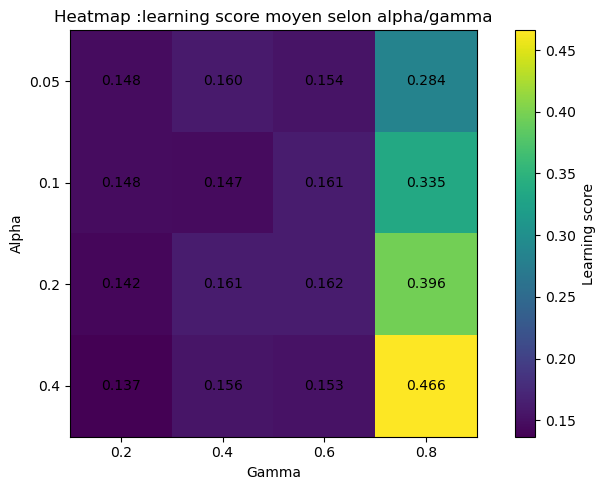

In [10]:
# Heatmap du learning_score selon alpha/gamma
pivot = summary_df.pivot(index="alpha", columns="gamma", values="learning_score")

fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(pivot.values)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("Gamma")
ax.set_ylabel("Alpha")
ax.set_title("Heatmap :learning score moyen selon alpha/gamma")

for row_index, alpha in enumerate(pivot.index):
    for col_index, gamma in enumerate(pivot.columns):
        value = pivot.loc[alpha, gamma]
        ax.text(col_index, row_index, f"{value:.3f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Learning score")
plt.tight_layout()
plt.show()


### Interprétation de la heatmap

La heatmap permet de voir rapidement quelle zone de paramètres est la plus performante.

Dans les résultats obtenus, la colonne `gamma = 0.8` ressort nettement.  
Cela indique que, pour Cubee, tenir compte du futur est important : un coup n'est pas seulement bon parce qu'il gagne immédiatement des cases, mais aussi parce qu'il prépare une meilleure situation plus tard.


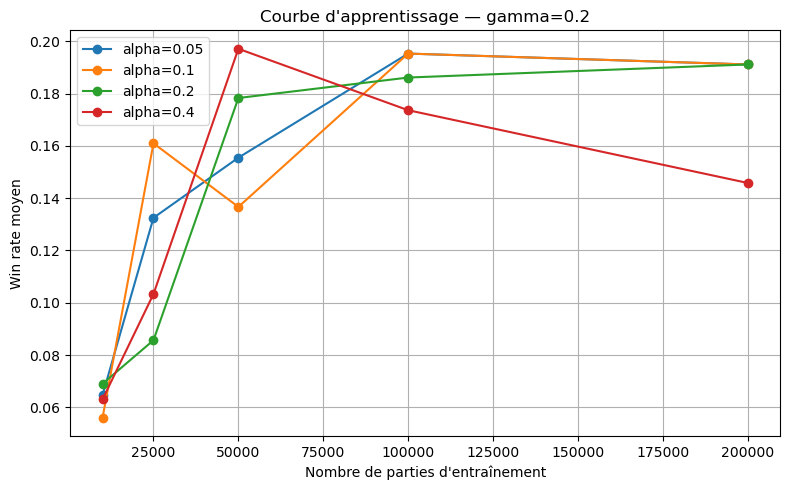

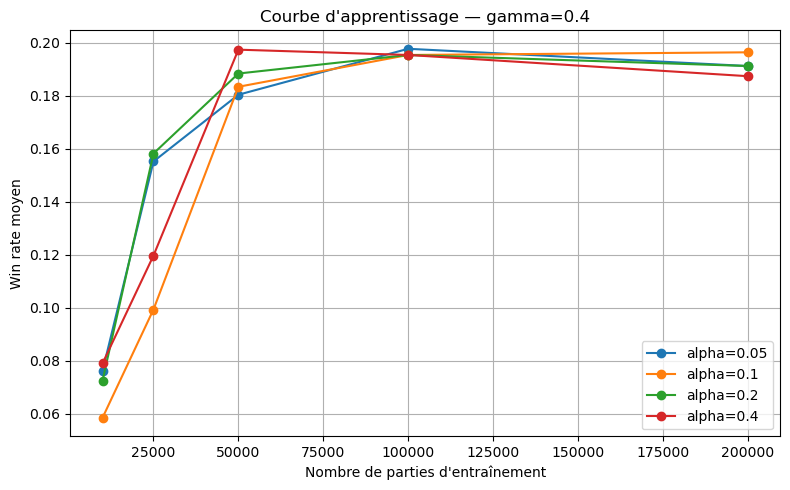

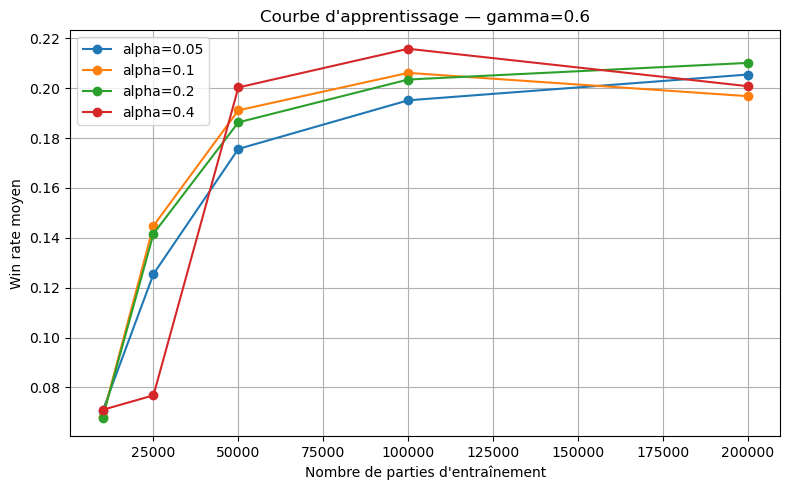

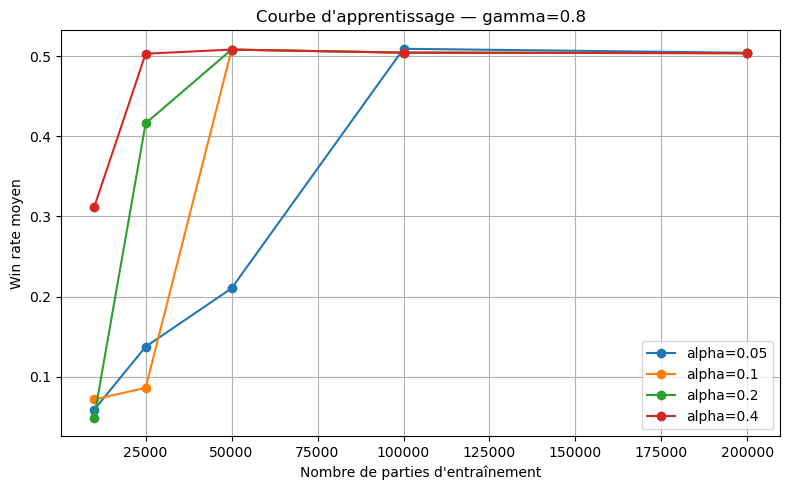

In [11]:
# Courbes d'apprentissage par alpha pour chaque gamma
grouped = (
    checkpoints_df
    .groupby(["alpha", "gamma", "checkpoint_games"], as_index=False)["win_rate"]
    .mean()
)

for gamma in sorted(grouped["gamma"].unique()):
    gamma_df = grouped[grouped["gamma"] == gamma]

    fig, ax = plt.subplots(figsize=(8, 5))

    for alpha in sorted(gamma_df["alpha"].unique()):
        alpha_df = gamma_df[gamma_df["alpha"] == alpha]
        ax.plot(
            alpha_df["checkpoint_games"],
            alpha_df["win_rate"],
            marker="o",
            label=f"alpha={alpha}",
        )

    ax.set_title(f"Courbe d'apprentissage — gamma={gamma}")
    ax.set_xlabel("Nombre de parties d'entraînement")
    ax.set_ylabel("Win rate moyen")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


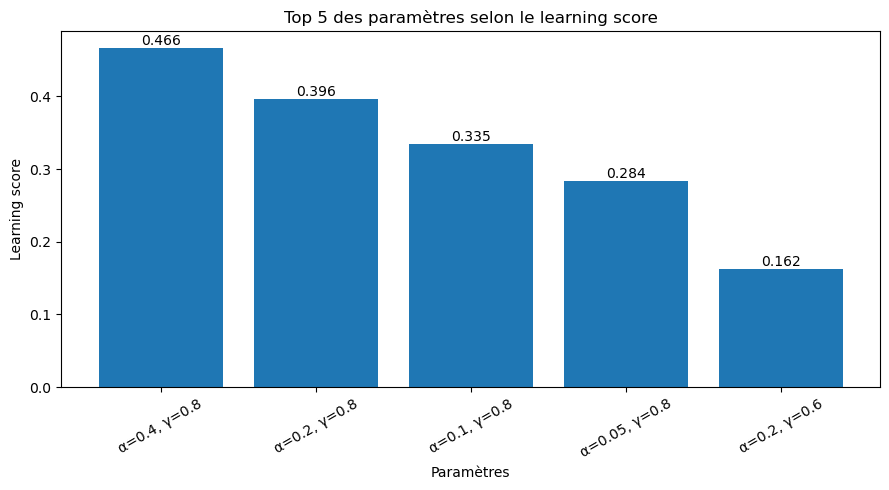

In [12]:
# Top 5 des couples de paramètres
top5 = summary_df.sort_values("learning_score", ascending=False).head(5).copy()
top5["label"] = top5.apply(lambda row: f"α={row['alpha']}, γ={row['gamma']}", axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(top5["label"], top5["learning_score"])

ax.set_title("Top 5 des paramètres selon le learning score")
ax.set_xlabel("Paramètres")
ax.set_ylabel("Learning score")
ax.tick_params(axis="x", rotation=30)

for index, value in enumerate(top5["learning_score"]):
    ax.text(index, value, f"{value:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


## Conclusion pour l'entraînement final

Paramètres retenus pour l'entraînement final:

```python
FINAL_ALPHA = 0.4
FINAL_GAMMA = 0.8
FINAL_BOARD_SIZE = 5
FINAL_SELF_PLAY_GAMES = 1_000_000
```

- Le tuning utilise un plateau `4x4` pour comparer les paramètres plus rapidement.
- L'entraînement final se fait ensuite en `5x5`, qui est le format final du jeu.
- `alpha = 0.4` est retenu car il obtient le meilleur score d'apprentissage.
- `gamma = 0.8` est retenu car les résultats montrent qu'il donne les meilleures performances.
- Le coefficient epsilon final est plus lent (`0.999997`) parce que l'entraînement final se fait sur 1000000 de parties.
